In [1]:
data_root = r"DATASET\Dataset_BUSI_with_GT"

In [4]:
import os, random, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [5]:
classes = ["benign", "malignant", "normal"]

clean_dir = "busi_clean"

for c in classes:
    os.makedirs(os.path.join(clean_dir, c), exist_ok=True)

for c in classes:
    folder = os.path.join(data_root, c)
    for img in os.listdir(folder):
        if img.endswith(".png") and "_mask" not in img:
            shutil.copy(
                os.path.join(folder, img),
                os.path.join(clean_dir, c, img)
            )

print("Clean dataset ready!")

Clean dataset ready!


In [6]:
base_dir = "busi_split"
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

for d in [train_dir, val_dir, test_dir]:
    for c in classes:
        os.makedirs(os.path.join(d, c), exist_ok=True)

for c in classes:
    images = os.listdir(os.path.join(clean_dir, c))

    train_imgs, temp = train_test_split(images, test_size=0.30, random_state=42)
    val_imgs, test_imgs = train_test_split(temp, test_size=0.50, random_state=42)

    for img in train_imgs:
        shutil.copy(os.path.join(clean_dir, c, img), os.path.join(train_dir, c, img))
    for img in val_imgs:
        shutil.copy(os.path.join(clean_dir, c, img), os.path.join(val_dir, c, img))
    for img in test_imgs:
        shutil.copy(os.path.join(clean_dir, c, img), os.path.join(test_dir, c, img))

print("Split completed!")

Split completed!


In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset   = ImageFolder(val_dir, transform=test_transform)
test_dataset  = ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16)
test_loader  = DataLoader(test_dataset, batch_size=16)

classes = train_dataset.classes
print("Classes:", classes)

Classes: ['benign', 'malignant', 'normal']


In [8]:
class DepthwiseBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, in_c, 3, stride, 1, groups=in_c),
            nn.ReLU(),
            nn.Conv2d(in_c, out_c, 1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)

class DepthwiseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1),
            nn.ReLU(),
            DepthwiseBlock(32, 64),
            DepthwiseBlock(64, 128, 2),
            DepthwiseBlock(128, 256, 2),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        return self.net(x)

In [9]:
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
resnet.fc = nn.Linear(resnet.fc.in_features, 3)
resnet = resnet.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\rajas/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [03:53<00:00, 440kB/s] 


In [13]:
labels = [label for _, label in train_data]

from collections import Counter
counts = Counter(labels)
total = sum(counts.values())

class_weights = torch.tensor(
    [total / (len(classes) * counts[i]) for i in range(len(classes))],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Class weights:", class_weights)

Class weights: tensor([0.5955, 1.2646, 1.8872])


In [14]:
def train(model, name, epochs=5):
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"{name} Epoch {epoch+1}: Loss = {total_loss/len(train_loader):.4f}")

    return model

In [15]:
def evaluate(model):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            out = model(x)
            _, preds = torch.max(out, 1)

            y_true.extend(y.numpy())
            y_pred.extend(preds.cpu().numpy())

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1:", f1_score(y_true, y_pred, average='weighted'))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True)
    plt.show()

In [16]:
print("Training ResNet50...")
resnet = train(resnet, "ResNet50")

print("\nTraining Depthwise CNN...")
dw_model = DepthwiseCNN().to(device)
dw_model = train(dw_model, "DepthwiseCNN")

Training ResNet50...
ResNet50 Epoch 1: Loss = 1.0615
ResNet50 Epoch 2: Loss = 0.8602
ResNet50 Epoch 3: Loss = 0.5880
ResNet50 Epoch 4: Loss = 0.5076
ResNet50 Epoch 5: Loss = 0.3637

Training Depthwise CNN...
DepthwiseCNN Epoch 1: Loss = 1.1026
DepthwiseCNN Epoch 2: Loss = 1.0996
DepthwiseCNN Epoch 3: Loss = 1.0981
DepthwiseCNN Epoch 4: Loss = 1.0973
DepthwiseCNN Epoch 5: Loss = 1.0973



ResNet50 Results:
Accuracy: 0.7627118644067796
Precision: 0.7978151791711113
Recall: 0.7627118644067796
F1: 0.7662087658943908


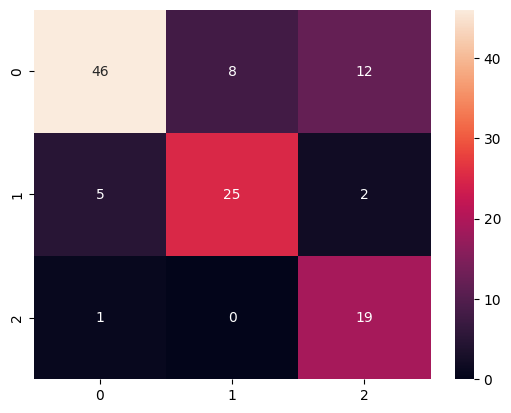


Depthwise CNN Results:
Accuracy: 0.559322033898305
Precision: 0.31284113760413673
Recall: 0.559322033898305
F1: 0.401252763448784


c:\Users\rajas\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


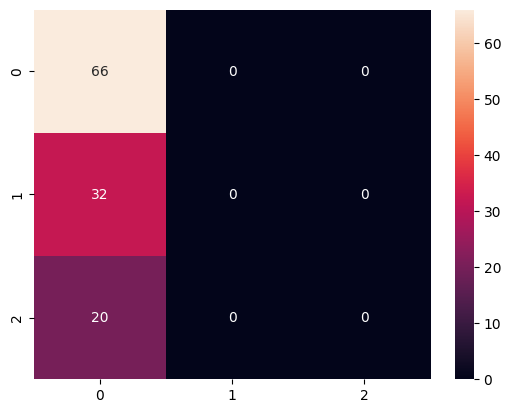

In [17]:
print("\nResNet50 Results:")
evaluate(resnet)

print("\nDepthwise CNN Results:")
evaluate(dw_model)

In [18]:
torch.save(resnet.state_dict(), "resnet50.pth")
torch.save(dw_model.state_dict(), "depthwise.pth")